# Phase 3: Physics-Informed Soil Moisture Model (All Constraints)

**Architecture:** Bi-LSTM backbone + FC regression head (pure PyTorch)

**Physics Constraints (8 total):**
1. Water Balance (ΔSM ≈ P_eff − ET − Drainage)
2. Vereecken Pedotransfer Bounds (θ_r, θ_s from clay/sand)
3. Soil Hysteresis (wetting vs drying Van Genuchten curves)
4. Temporal Laplacian Smoothing (anti-zigzag)
5. Dynamic Lambda (regime-aware physics weighting)
6. Monotonic Drying (SM must not increase when P≈0)
7. NDVI-scaled ET (vegetation-aware evapotranspiration)
8. Infiltration/Runoff + Gravity Drainage

In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Import our physics module
from physics_model import (
    vereecken_parameters, PhysicsSoilMoistureModel,
    WaterBalancePhysicsLoss, HysteresisPhysicsLoss,
    TemporalLaplacianLoss, MonotonicDryingLoss,
    compute_dynamic_lambda, AdaptiveLossWeights
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print('All physics modules loaded successfully!')

import importlib
import sys
if 'physics_model' in sys.modules:
    importlib.reload(sys.modules['physics_model'])


Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
All physics modules loaded successfully!


## 1. Load Data & Compute Soil Parameters

In [3]:
# --- Load CSV ---
df = pd.read_csv('roi_aligned_timeseries_2021_2025.csv')
if 'constant' in df.columns:
    df.drop(columns=['constant'], inplace=True)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
if df.isnull().values.any():
    df.fillna(method='ffill', inplace=True)
    df.fillna(method='bfill', inplace=True)
df.set_index('date', inplace=True)

# --- Vereecken Pedotransfer Equations ---
clay_pct = df['clay'].iloc[0]
sand_pct = df['sand'].iloc[0]
soil_params = vereecken_parameters(clay_pct, sand_pct)

print(f'Dataset: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\n--- Vereecken Soil Parameters ---')
print(f'  Clay: {clay_pct:.2f}%  |  Sand: {sand_pct:.2f}%')
print(f'  θ_r (residual):       {soil_params["theta_r"]:.4f} m³/m³')
print(f'  θ_s (saturation):     {soil_params["theta_s"]:.4f} m³/m³')
print(f'  θ_fc (field capacity): {soil_params["theta_fc"]:.4f} m³/m³')
print(f'  α (Van Genuchten):    {soil_params["alpha_vg"]:.6f} 1/cm')
print(f'  n (Van Genuchten):    {soil_params["n_vg"]:.4f}')
print(f'\n--- Observed SM Range ---')
print(f'  Min: {df["sm_surface"].min():.4f}  |  Max: {df["sm_surface"].max():.4f}')
display(df.head())

Dataset: (1826, 15)
Columns: ['potential_evaporation', 'sm_surface', 'temperature_2m', 'total_precipitation', 'B2', 'B3', 'B4', 'B8', 'NDVI', 'VH', 'VV', 'clay', 'elevation', 'sand', 'slope']

--- Vereecken Soil Parameters ---
  Clay: 27.12%  |  Sand: 37.43%
  θ_r (residual):       0.0200 m³/m³
  θ_s (saturation):     0.4268 m³/m³
  θ_fc (field capacity): 0.3047 m³/m³
  α (Van Genuchten):    0.002036 1/cm
  n (Van Genuchten):    1.6530

--- Observed SM Range ---
  Min: 0.0216  |  Max: 0.3861


,potential_evaporation,sm_surface,temperature_2m,total_precipitation,B2,B3,B4,B8,NDVI,VH,VV,clay,elevation,sand,slope
date,,,,,,,,,,,,,,,
2021-01-01,-0.064895,0.159273,287.775122,8.557963e-07,1144.752482,1332.601722,1166.394398,2386.942911,0.345933,-17.386736,-9.682761,27.116309,98.550338,37.425355,0.197415
2021-01-02,-0.059693,0.158111,289.226754,2.312732e-07,1144.752482,1332.601722,1166.394398,2386.942911,0.345933,-17.386736,-9.682761,27.116309,98.550338,37.425355,0.197415
2021-01-03,-0.059155,0.158204,290.845856,7.735890e-06,1144.752482,1332.601722,1166.394398,2386.942911,0.345933,-17.386736,-9.682761,27.116309,98.550338,37.425355,0.197415
2021-01-04,-0.060549,0.172161,292.214553,9.411331e-06,1106.706116,1268.856384,1182.136765,2244.874586,0.317548,-17.412232,-10.193458,27.116309,98.550338,37.425355,0.197415
2021-01-05,-0.042654,0.175980,292.534701,3.264632e-04,1068.659750,1205.111047,1197.879132,2102.806262,0.289162,-17.437728,-10.704155,27.116309,98.550338,37.425355,0.197415


## 2. Scale, Sequence, and Split

In [4]:
# --- Scale features ---
target_col = 'sm_surface'
feature_cols = [c for c in df.columns if c != target_col]
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = X_scaler.fit_transform(df[feature_cols])
df_scaled[[target_col]] = y_scaler.fit_transform(df[[target_col]])

# --- Store raw columns for physics losses and plotting ---
raw_precip = df['total_precipitation'].values
raw_pe = df['potential_evaporation'].values
raw_sm = df['sm_surface'].values
raw_temp = df['temperature_2m'].values

# --- Create sequences ---
SEQ_LENGTH = 14
def create_sequences(data, target_col_idx, seq_length):
    xs, ys = [], []
    data_array = data.values
    for i in range(len(data_array) - seq_length):
        xs.append(data_array[i:(i + seq_length)])
        ys.append(data_array[i + seq_length, target_col_idx])
    return np.array(xs), np.array(ys)

target_idx = df_scaled.columns.get_loc(target_col)
X, y = create_sequences(df_scaled, target_idx, SEQ_LENGTH)

# Raw physics arrays aligned with sequences
raw_sm_targets = raw_sm[SEQ_LENGTH:]
raw_sm_prev = raw_sm[SEQ_LENGTH - 1:-1]
raw_precip_targets = raw_precip[SEQ_LENGTH:]
raw_pe_targets = raw_pe[SEQ_LENGTH:]

# Also create raw (unscaled) input sequences for Laplacian loss
raw_df_values = df.values  # unscaled
X_raw = np.array([raw_df_values[i:(i + SEQ_LENGTH)] for i in range(len(raw_df_values) - SEQ_LENGTH)])

print(f'X shape: {X.shape}  |  y shape: {y.shape}')
print(f'X_raw shape: {X_raw.shape}')

X shape: (1812, 14, 15)  |  y shape: (1812,)
X_raw shape: (1812, 14, 15)


In [5]:
# --- Train/Val/Test split (monsoon holdout) ---
seq_dates = df_scaled.index[SEQ_LENGTH:]
monsoon_months = [6, 7, 8, 9]
test_mask = seq_dates.month.isin(monsoon_months)
train_val_mask = ~test_mask

# Test
X_test, y_test = X[test_mask], y[test_mask]
X_test_raw = X_raw[test_mask]
test_sm_prev = raw_sm_prev[test_mask]
test_precip = raw_precip_targets[test_mask]
test_pe = raw_pe_targets[test_mask]

# Train/Val
X_tv, y_tv = X[train_val_mask], y[train_val_mask]
X_tv_raw = X_raw[train_val_mask]
tv_sm_prev = raw_sm_prev[train_val_mask]
tv_precip = raw_precip_targets[train_val_mask]
tv_pe = raw_pe_targets[train_val_mask]

split_idx = int(len(X_tv) * 0.8)
X_train, y_train = X_tv[:split_idx], y_tv[:split_idx]
X_val, y_val = X_tv[split_idx:], y_tv[split_idx:]
X_train_raw = X_tv_raw[:split_idx]

train_sm_prev = tv_sm_prev[:split_idx]
train_precip = tv_precip[:split_idx]
train_pe = tv_pe[:split_idx]

val_sm_prev = tv_sm_prev[split_idx:]
val_precip = tv_precip[split_idx:]
val_pe = tv_pe[split_idx:]

print(f'Training:   {X_train.shape[0]} samples')
print(f'Validation: {X_val.shape[0]} samples')
print(f'Test:       {X_test.shape[0]} samples')

Training:   961 samples
Validation: 241 samples
Test:       610 samples


In [6]:
# --- Convert to tensors ---
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

# Physics tensors
train_sm_prev_t = torch.tensor(train_sm_prev, dtype=torch.float32).unsqueeze(1).to(device)
train_precip_t  = torch.tensor(train_precip, dtype=torch.float32).unsqueeze(1).to(device)
train_pe_t      = torch.tensor(train_pe, dtype=torch.float32).unsqueeze(1).to(device)
X_train_raw_t   = torch.tensor(X_train_raw, dtype=torch.float32).to(device)

print('All tensors created and moved to device.')

All tensors created and moved to device.


## 3. Build Model & Physics Losses

In [7]:
# --- Bi-LSTM Model ---
model = PhysicsSoilMoistureModel(
    n_features=len(df_scaled.columns),
    hidden_size=128,
    lstm_layers=2,
    dropout=0.2
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

# --- Physics Loss Modules ---
sp = soil_params
sm_min, sm_max = y_scaler.data_min_[0], y_scaler.data_max_[0]

wb_loss_fn   = WaterBalancePhysicsLoss(sp['theta_r'], sp['theta_s'], sp['theta_fc']).to(device)
hyst_loss_fn = HysteresisPhysicsLoss(sp['theta_r'], sp['theta_s'], sp['alpha_vg'], sp['n_vg']).to(device)
lap_loss_fn  = TemporalLaplacianLoss(sm_col_idx=0, precip_col_idx=2).to(device)
mono_loss_fn = MonotonicDryingLoss().to(device)
data_loss_fn = nn.MSELoss()

print(f'\nPhysics modules ready.')
print(f'  θ_r={sp["theta_r"]:.4f}, θ_s={sp["theta_s"]:.4f}, θ_fc={sp["theta_fc"]:.4f}')

PhysicsSoilMoistureModel(
  (lstm): LSTM(15, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (head): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): SiLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): SiLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 562,305

Physics modules ready.
  θ_r=0.0200, θ_s=0.4268, θ_fc=0.3047


## 4. Training Loop (All Physics Constraints)

In [8]:
# --- Hyperparameters ---
EPOCHS = 200
LEARNING_RATE = 1e-3
BATCH_SIZE = 64
# Physics loss weights (kept conservative to avoid over-regularizing data fit)
LAMBDA_WB_BASE = 0.10   # water balance (dynamic per batch)
LAMBDA_HYST    = 0.01   # hysteresis bounds
LAMBDA_LAP     = 0.001  # Laplacian smoothing
LAMBDA_MONO    = 0.01   # monotonic drying

# Optimizer (model params + learnable water-balance coefficients)
all_params = list(model.parameters()) + list(wb_loss_fn.parameters())
optimizer = torch.optim.Adam(all_params, lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)

# --- DataLoader ---
train_dataset = torch.utils.data.TensorDataset(
    X_train_t, y_train_t, train_sm_prev_t, train_precip_t, train_pe_t, X_train_raw_t
)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# --- History ---
history = {
    'train_total': [], 'train_data': [], 'train_wb': [],
    'train_hyst': [], 'train_lap': [], 'train_mono': [],
    'val_loss': [], 'alpha': [], 'beta': [], 'gamma': []
}

best_val_loss = float('inf')
best_model_state = None

print(f'Training for {EPOCHS} epochs | Batch size: {BATCH_SIZE}')
print(f'Lambda: WB(dynamic,base={LAMBDA_WB_BASE}), Hyst={LAMBDA_HYST}, Lap={LAMBDA_LAP}, Mono={LAMBDA_MONO}')
print('-' * 80)

for epoch in range(EPOCHS):
    model.train()
    ep = {k: 0.0 for k in ['data', 'wb', 'hyst', 'lap', 'mono', 'total']}
    n_batches = 0

    for batch_x, batch_y, b_sm_prev, b_precip, b_pe, b_x_raw in train_loader:
        optimizer.zero_grad()
        pred = model(batch_x)

        # Convert prediction to raw scale for physics terms
        pred_raw = pred * (sm_max - sm_min) + sm_min

        # Loss components
        d_loss = data_loss_fn(pred, batch_y)
        wb_loss = wb_loss_fn(pred_raw, b_sm_prev, b_precip, b_pe)
        h_loss = hyst_loss_fn(pred_raw, b_precip)
        l_loss = lap_loss_fn(b_x_raw)
        m_loss = mono_loss_fn(pred_raw, b_sm_prev, b_precip)

        # Dynamic lambda (higher trust in physics on dry days)
        batch_lambda_wb = compute_dynamic_lambda(b_precip, LAMBDA_WB_BASE).mean()

        # Explicit weighted objective (avoids conflicting adaptive/dynamic weighting)
        total_loss = (
            d_loss
            + batch_lambda_wb * wb_loss
            + LAMBDA_HYST * h_loss
            + LAMBDA_LAP * l_loss
            + LAMBDA_MONO * m_loss
        )

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        ep['data'] += d_loss.item()
        ep['wb'] += wb_loss.item()
        ep['hyst'] += h_loss.item()
        ep['lap'] += l_loss.item()
        ep['mono'] += m_loss.item()
        ep['total'] += total_loss.item()
        n_batches += 1

    for k in ep:
        ep[k] /= n_batches

    # Validation (data fit only)
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = data_loss_fn(val_pred, y_val_t).item()
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    history['train_total'].append(ep['total'])
    history['train_data'].append(ep['data'])
    history['train_wb'].append(ep['wb'])
    history['train_hyst'].append(ep['hyst'])
    history['train_lap'].append(ep['lap'])
    history['train_mono'].append(ep['mono'])
    history['val_loss'].append(val_loss)
    history['alpha'].append(wb_loss_fn.alpha.item())
    history['beta'].append(wb_loss_fn.beta.item())
    history['gamma'].append(wb_loss_fn.gamma.item())

    if (epoch + 1) % 20 == 0:
        print(
            f'Ep {epoch+1:3d}/{EPOCHS} | '
            f'Total:{ep["total"]:.5f} Data:{ep["data"]:.5f} WB:{ep["wb"]:.5f} '
            f'Hyst:{ep["hyst"]:.5f} Lap:{ep["lap"]:.5f} Mono:{ep["mono"]:.5f} | '
            f'Val:{val_loss:.5f} | α:{wb_loss_fn.alpha.item():.4f} '
            f'β:{wb_loss_fn.beta.item():.6f} γ:{wb_loss_fn.gamma.item():.5f}'
        )

print('-' * 80)
print(f'Training complete! Best val loss: {best_val_loss:.6f}')
model.load_state_dict(best_model_state)

Training for 200 epochs | Batch size: 64
Lambda: WB(dynamic,base=0.1), Hyst=0.01, Lap=0.001, Mono=0.01
--------------------------------------------------------------------------------
Ep  20/200 | Total:0.00428 Data:0.00356 WB:0.00752 Hyst:0.00014 Lap:0.00019 Mono:0.00008 | Val:0.00318 | α:0.9269 β:0.720511 γ:0.00397
Ep  40/200 | Total:0.00198 Data:0.00165 WB:0.00415 Hyst:0.00000 Lap:0.00019 Mono:0.00001 | Val:0.00355 | α:0.8590 β:0.492961 γ:-0.00844
Ep  60/200 | Total:0.00215 Data:0.00200 WB:0.00160 Hyst:0.00000 Lap:0.00020 Mono:0.00002 | Val:0.00373 | α:0.7750 β:0.316257 γ:0.00204
Ep  80/200 | Total:0.00132 Data:0.00126 WB:0.00063 Hyst:0.00000 Lap:0.00021 Mono:0.00001 | Val:0.00202 | α:0.6776 β:0.185414 γ:0.03012
Ep 100/200 | Total:0.00110 Data:0.00108 WB:0.00028 Hyst:0.00000 Lap:0.00021 Mono:0.00001 | Val:0.00178 | α:0.5748 β:0.102051 γ:0.06626
Ep 120/200 | Total:0.00118 Data:0.00116 WB:0.00019 Hyst:0.00000 Lap:0.00020 Mono:0.00001 | Val:0.00196 | α:0.4938 β:0.059660 γ:0.10447
Ep 14

<All keys matched successfully>

## 5. Training Visualization

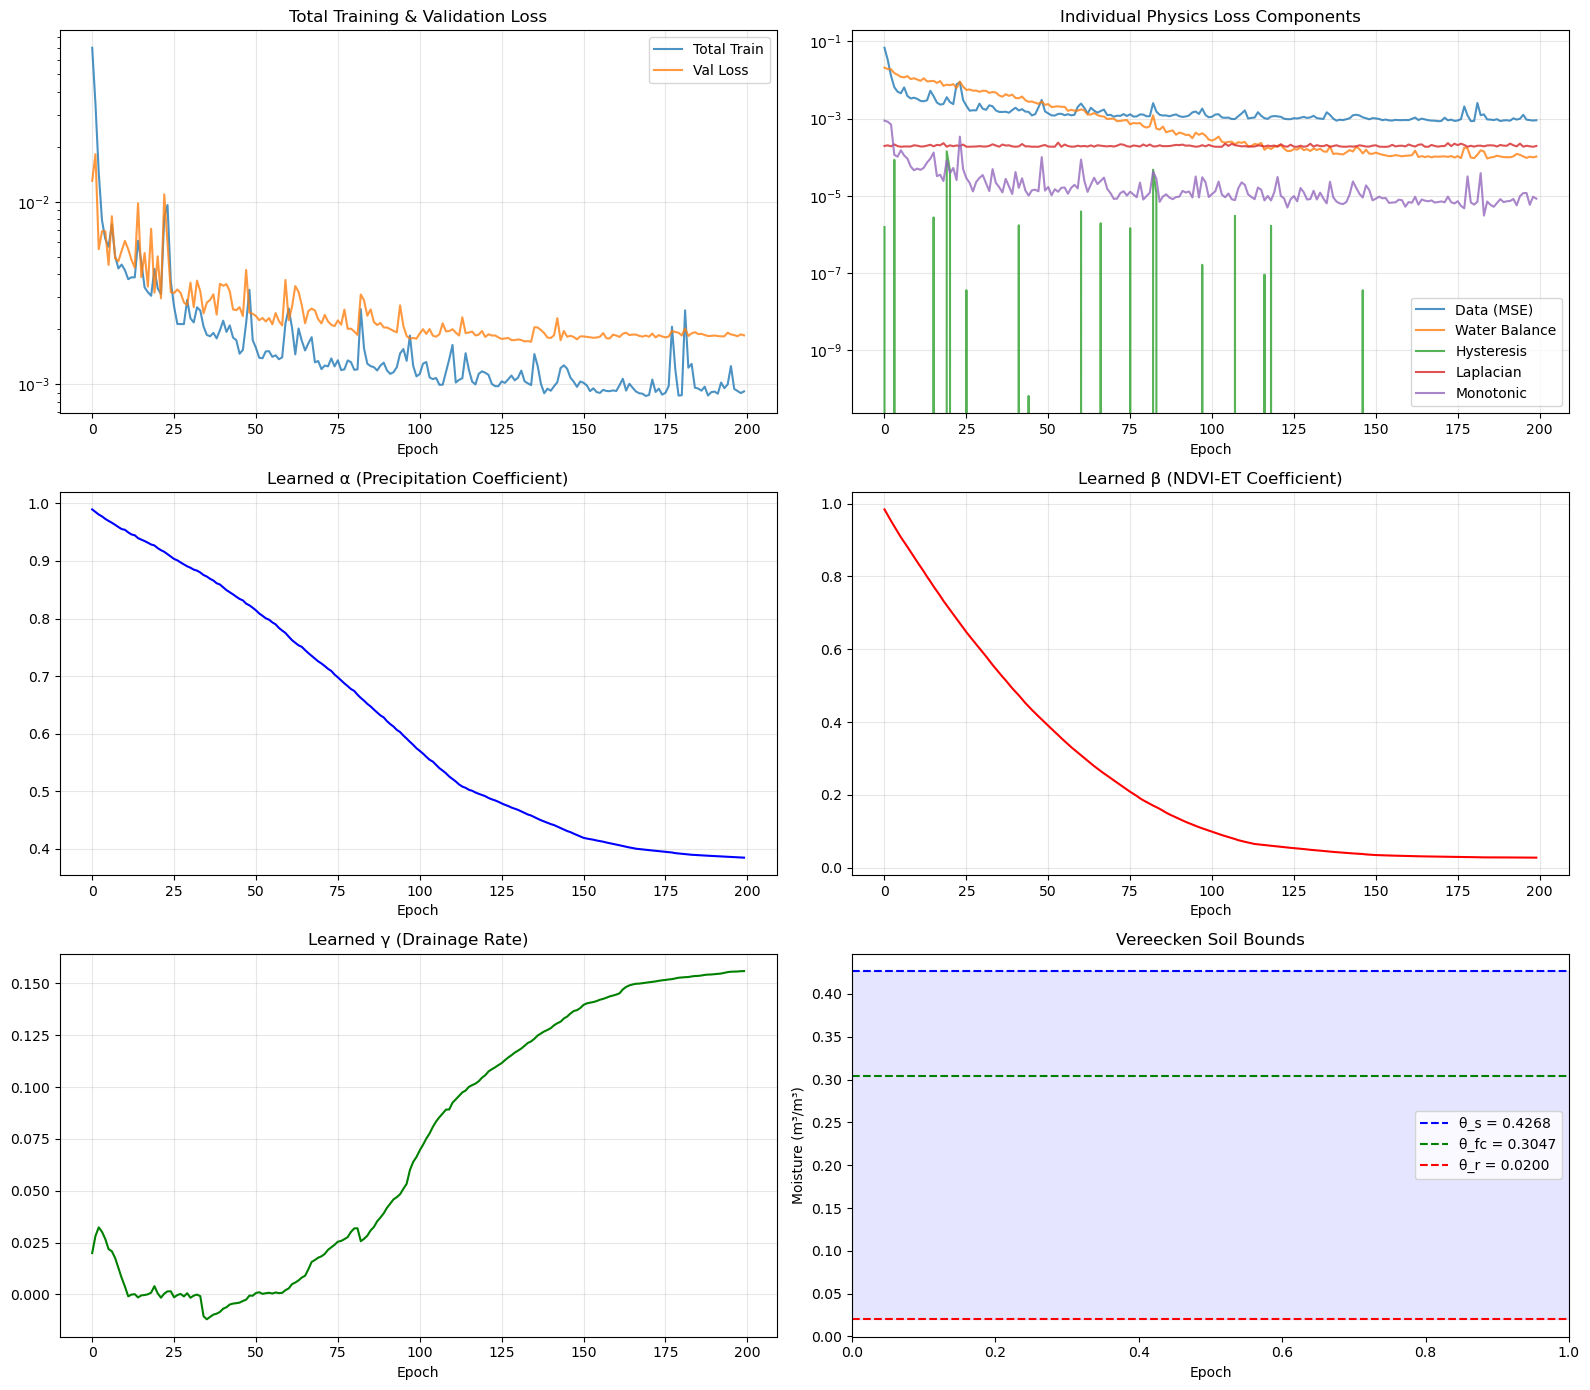

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Total + Val loss
axes[0,0].plot(history['train_total'], label='Total Train', alpha=0.8)
axes[0,0].plot(history['val_loss'], label='Val Loss', alpha=0.8)
axes[0,0].set_title('Total Training & Validation Loss')
axes[0,0].legend(); axes[0,0].set_yscale('log'); axes[0,0].grid(True, alpha=0.3)

# All component losses
axes[0,1].plot(history['train_data'], label='Data (MSE)', alpha=0.8)
axes[0,1].plot(history['train_wb'], label='Water Balance', alpha=0.8)
axes[0,1].plot(history['train_hyst'], label='Hysteresis', alpha=0.8)
axes[0,1].plot(history['train_lap'], label='Laplacian', alpha=0.8)
axes[0,1].plot(history['train_mono'], label='Monotonic', alpha=0.8)
axes[0,1].set_title('Individual Physics Loss Components')
axes[0,1].legend(); axes[0,1].set_yscale('log'); axes[0,1].grid(True, alpha=0.3)

# Alpha
axes[1,0].plot(history['alpha'], color='blue')
axes[1,0].set_title('Learned α (Precipitation Coefficient)')
axes[1,0].grid(True, alpha=0.3)

# Beta
axes[1,1].plot(history['beta'], color='red')
axes[1,1].set_title('Learned β (NDVI-ET Coefficient)')
axes[1,1].grid(True, alpha=0.3)

# Gamma
axes[2,0].plot(history['gamma'], color='green')
axes[2,0].set_title('Learned γ (Drainage Rate)')
axes[2,0].grid(True, alpha=0.3)

# Soil bounds reference
axes[2,1].axhline(y=soil_params['theta_s'], color='blue', linestyle='--', label=f'θ_s = {soil_params["theta_s"]:.4f}')
axes[2,1].axhline(y=soil_params['theta_fc'], color='green', linestyle='--', label=f'θ_fc = {soil_params["theta_fc"]:.4f}')
axes[2,1].axhline(y=soil_params['theta_r'], color='red', linestyle='--', label=f'θ_r = {soil_params["theta_r"]:.4f}')
axes[2,1].fill_between([0,1], soil_params['theta_r'], soil_params['theta_s'], alpha=0.1, color='blue')
axes[2,1].set_title('Vereecken Soil Bounds'); axes[2,1].legend()
axes[2,1].set_xlim(0,1); axes[2,1].set_ylabel('Moisture (m³/m³)')

for ax in axes.flat: ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluate on Test Set (Monsoon Holdout)

In [10]:
model.eval()
with torch.no_grad():
    test_pred_scaled = model(X_test_t).cpu().numpy()
    train_pred_scaled = model(X_train_t).cpu().numpy()

test_pred_raw = y_scaler.inverse_transform(test_pred_scaled)
test_actual_raw = y_scaler.inverse_transform(y_test.reshape(-1, 1))
train_pred_raw = y_scaler.inverse_transform(train_pred_scaled)
train_actual_raw = y_scaler.inverse_transform(y_train.reshape(-1, 1))

test_rmse = np.sqrt(mean_squared_error(test_actual_raw, test_pred_raw))
test_mae = mean_absolute_error(test_actual_raw, test_pred_raw)
test_r2 = r2_score(test_actual_raw, test_pred_raw)
train_rmse = np.sqrt(mean_squared_error(train_actual_raw, train_pred_raw))
train_r2 = r2_score(train_actual_raw, train_pred_raw)

# Check bounds compliance
n_over = np.sum(test_pred_raw > soil_params['theta_s'])
n_under = np.sum(test_pred_raw < soil_params['theta_r'])

print('=' * 60)
print('       MODEL EVALUATION RESULTS ')
print('=' * 60)
print(f'\nTraining Set:  RMSE={train_rmse:.6f}  R²={train_r2:.4f}')
print(f'Test Set:      RMSE={test_rmse:.6f}  MAE={test_mae:.6f}  R²={test_r2:.4f}')
print(f'\nBounds Compliance (Test Set):')
print(f'  Predictions > θ_s ({soil_params["theta_s"]:.4f}): {n_over}/{len(test_pred_raw)}')
print(f'  Predictions < θ_r ({soil_params["theta_r"]:.4f}): {n_under}/{len(test_pred_raw)}')
print(f'\nLearned Physics Coefficients:')
print(f'  α (precip):    {wb_loss_fn.alpha.item():.6f}')
print(f'  β (NDVI-ET):   {wb_loss_fn.beta.item():.6f}')
print(f'  γ (drainage):  {wb_loss_fn.gamma.item():.6f}')

       MODEL EVALUATION RESULTS 

Training Set:  RMSE=0.010578  R²=0.9779
Test Set:      RMSE=0.022998  MAE=0.017442  R²=0.9452

Bounds Compliance (Test Set):
  Predictions > θ_s (0.4268): 0/610
  Predictions < θ_r (0.0200): 0/610

Learned Physics Coefficients:
  α (precip):    0.384966
  β (NDVI-ET):   0.027887
  γ (drainage):  0.155895


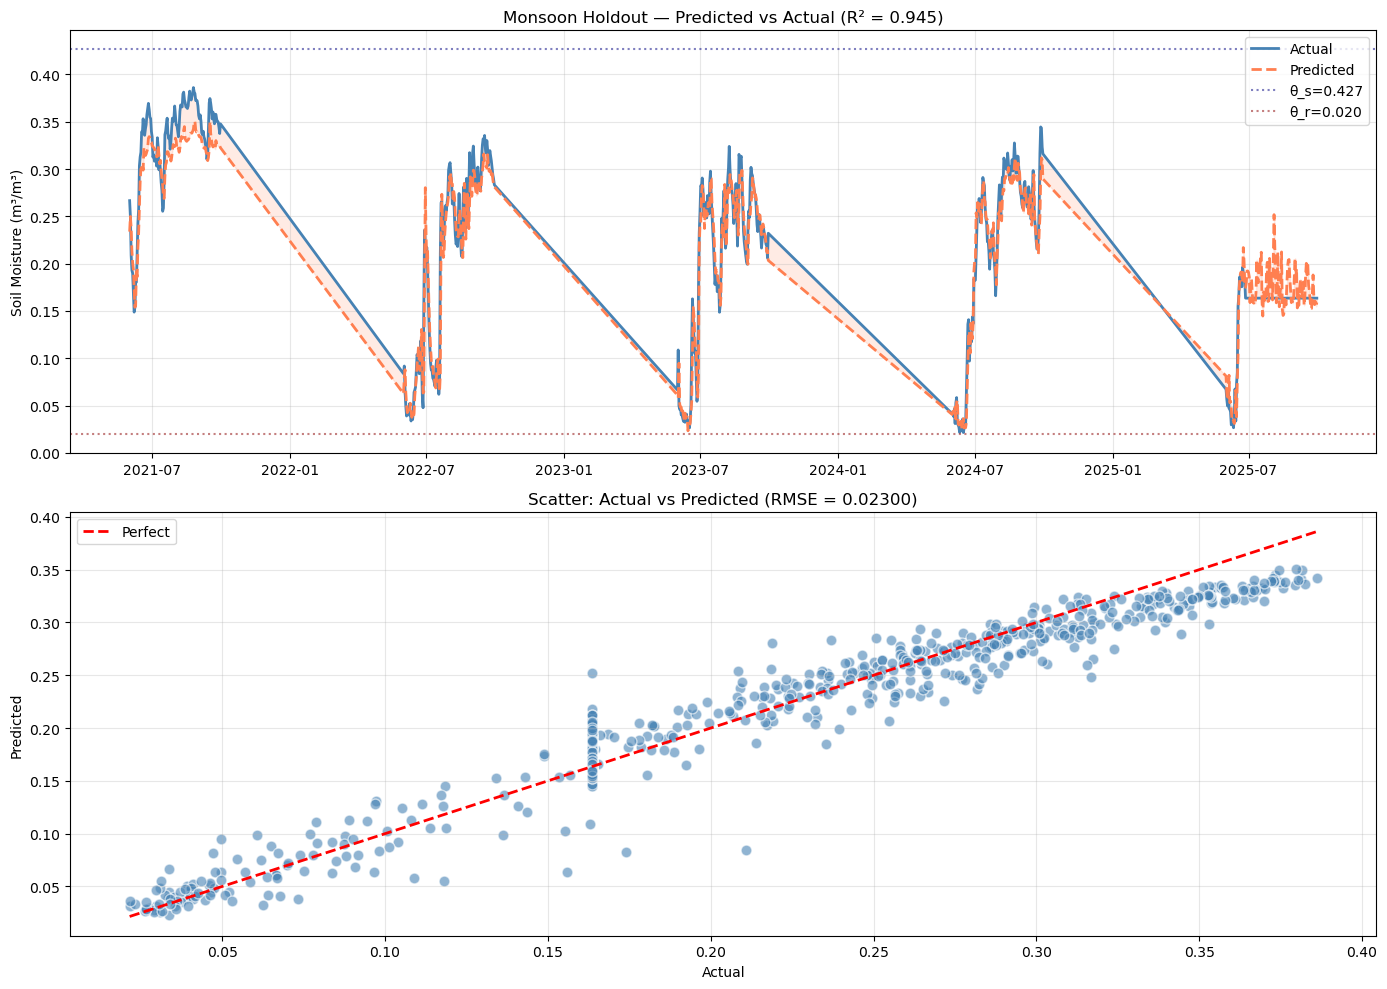

In [11]:
test_dates = seq_dates[test_mask]
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Time series
axes[0].plot(test_dates, test_actual_raw, label='Actual', color='steelblue', linewidth=2)
axes[0].plot(test_dates, test_pred_raw, label='Predicted', color='coral', linewidth=2, linestyle='--')
axes[0].axhline(y=soil_params['theta_s'], color='navy', linestyle=':', alpha=0.5, label=f'θ_s={soil_params["theta_s"]:.3f}')
axes[0].axhline(y=soil_params['theta_r'], color='darkred', linestyle=':', alpha=0.5, label=f'θ_r={soil_params["theta_r"]:.3f}')
axes[0].fill_between(test_dates, test_actual_raw.flatten(), test_pred_raw.flatten(), alpha=0.15, color='coral')
axes[0].set_ylabel('Soil Moisture (m³/m³)')
axes[0].set_title(f'Monsoon Holdout — Predicted vs Actual (R² = {test_r2:.3f})')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

# Scatter
axes[1].scatter(test_actual_raw, test_pred_raw, alpha=0.6, color='steelblue', edgecolors='white', s=60)
mn, mx = min(test_actual_raw.min(), test_pred_raw.min()), max(test_actual_raw.max(), test_pred_raw.max())
axes[1].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Scatter: Actual vs Predicted (RMSE = {test_rmse:.5f})')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('test_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Full Year Visualization

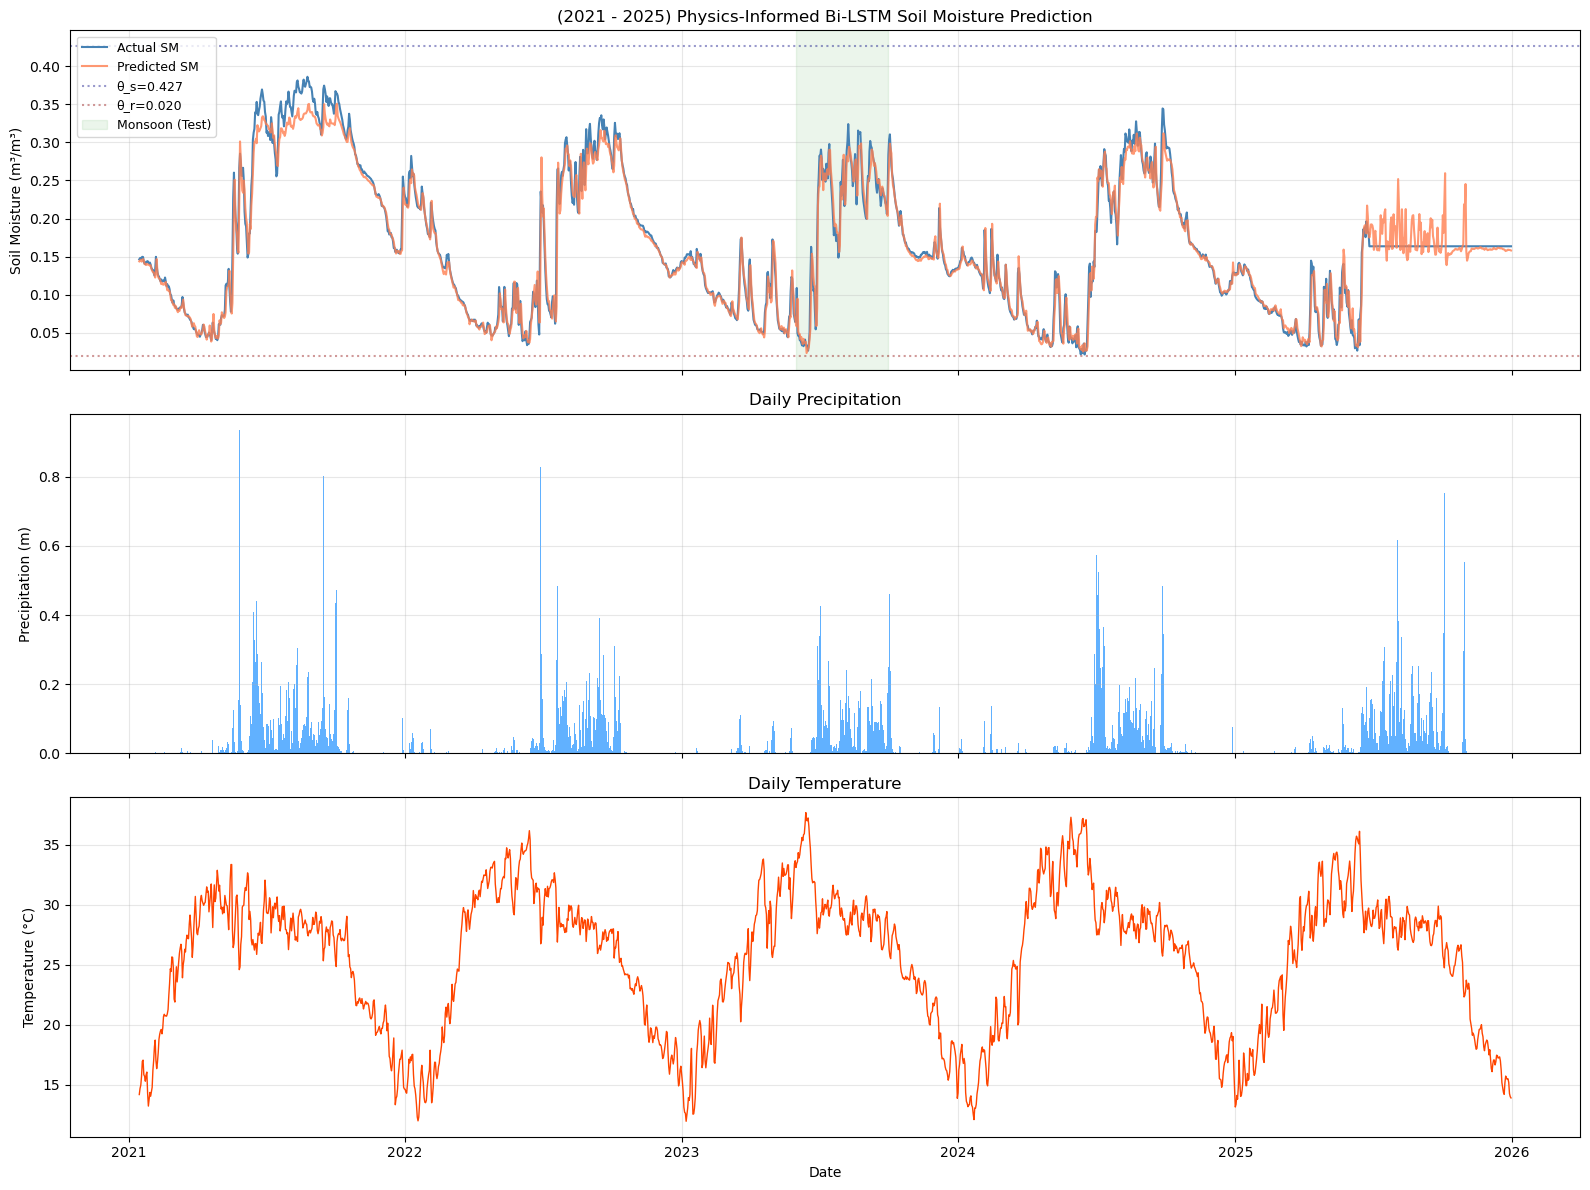

In [12]:
X_all_t = torch.tensor(X, dtype=torch.float32).to(device)
model.eval()
with torch.no_grad():
    all_pred_scaled = model(X_all_t).cpu().numpy()
all_pred_raw = y_scaler.inverse_transform(all_pred_scaled)
all_actual_raw = y_scaler.inverse_transform(y.reshape(-1, 1))

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
all_dates = seq_dates

# SM
axes[0].plot(all_dates, all_actual_raw, label='Actual SM', color='steelblue', linewidth=1.5)
axes[0].plot(all_dates, all_pred_raw, label='Predicted SM', color='coral', linewidth=1.5, alpha=0.8)
axes[0].axhline(y=soil_params['theta_s'], color='navy', linestyle=':', alpha=0.4, label=f'θ_s={soil_params["theta_s"]:.3f}')
axes[0].axhline(y=soil_params['theta_r'], color='darkred', linestyle=':', alpha=0.4, label=f'θ_r={soil_params["theta_r"]:.3f}')
axes[0].axvspan(pd.Timestamp('2023-06-01'), pd.Timestamp('2023-09-30'), alpha=0.08, color='green', label='Monsoon (Test)')
axes[0].set_ylabel('Soil Moisture (m³/m³)')
axes[0].set_title('(2021 - 2025) Physics-Informed Bi-LSTM Soil Moisture Prediction')
axes[0].legend(loc='upper left', fontsize=9); axes[0].grid(True, alpha=0.3)

# Precip
axes[1].bar(all_dates, raw_precip[SEQ_LENGTH:], color='dodgerblue', alpha=0.7, width=1)
axes[1].set_ylabel('Precipitation (m)'); axes[1].set_title('Daily Precipitation')
axes[1].grid(True, alpha=0.3)

# Temp
axes[2].plot(all_dates, raw_temp[SEQ_LENGTH:] - 273.15, color='orangered', linewidth=1)
axes[2].set_ylabel('Temperature (°C)'); axes[2].set_xlabel('Date')
axes[2].set_title('Daily Temperature'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('full_year_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Model

In [13]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'wb_loss_state_dict': wb_loss_fn.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'soil_params': soil_params,
    'hyperparameters': {
        'seq_length': SEQ_LENGTH,
        'n_features': len(df_scaled.columns),
        'hidden_size': 128,
        'lstm_layers': 2,
        'lambda_wb_base': LAMBDA_WB_BASE,
        'lambda_hyst': LAMBDA_HYST,
        'lambda_lap': LAMBDA_LAP,
        'lambda_mono': LAMBDA_MONO,
        'learning_rate': LEARNING_RATE,
    },
    'metrics': {
        'test_rmse': test_rmse, 'test_mae': test_mae, 'test_r2': test_r2,
        'learned_alpha': wb_loss_fn.alpha.item(),
        'learned_beta': wb_loss_fn.beta.item(),
        'learned_gamma': wb_loss_fn.gamma.item(),
    },
    'physics_constraints': [
        '1. Water Balance (P_eff - ET - Drainage)',
        '2. Vereecken Pedotransfer Bounds',
        '3. Soil Hysteresis (Van Genuchten wetting/drying)',
        '4. Temporal Laplacian Smoothing',
        '5. Dynamic Lambda (regime-aware)',
        '6. Monotonic Drying Constraint',
        '7. NDVI-scaled Evapotranspiration',
        '8. Infiltration/Runoff + Gravity Drainage'
    ]
}
torch.save(checkpoint, 'physics_sm_model.pt')
print('Model saved to physics_sm_model.pt')
print(f'\nFinal learned coefficients:')
print(f'  α (precipitation):  {wb_loss_fn.alpha.item():.6f}')
print(f'  β (NDVI-ET):        {wb_loss_fn.beta.item():.6f}')
print(f'  γ (drainage):       {wb_loss_fn.gamma.item():.6f}')

Model saved to physics_sm_model.pt

Final learned coefficients:
  α (precipitation):  0.384966
  β (NDVI-ET):        0.027887
  γ (drainage):       0.155895


---
## 8. Seasonal Performance Analysis
Breaks test-set metrics by **monsoon (Jun–Sep)** vs **non-monsoon** seasons.  
Required in hydrology / remote-sensing papers to show the model generalises across wet and dry regimes.


── Seasonal Performance ──
                         RMSE (m³/m³)  MAE (m³/m³)      R²
Non-monsoon (train+val)        0.0116       0.0066  0.9708
Monsoon (test)                 0.0230       0.0174  0.9452
Overall                        0.0164       0.0103  0.9664


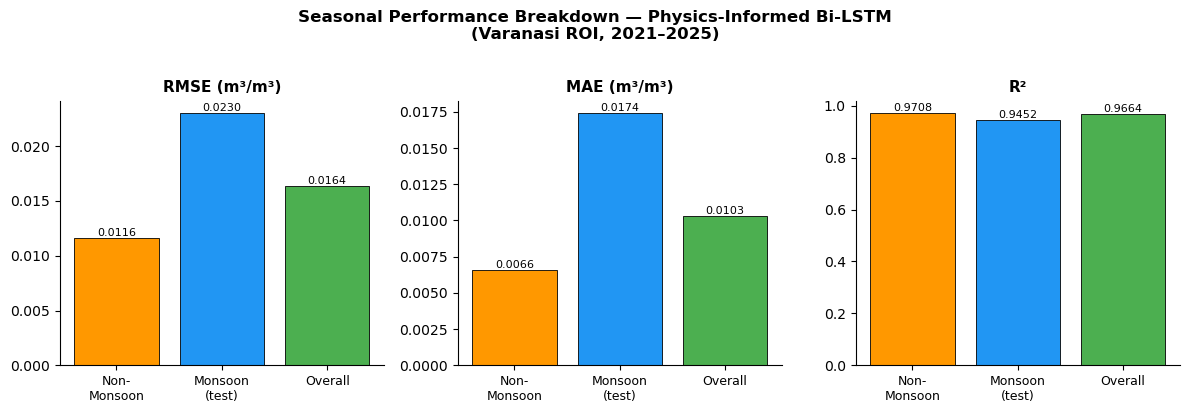

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Inference on all splits ─────────────────────────────────────────────────
# The original train/val splits are non-monsoon. Test split is monsoon.
model.eval()
with torch.no_grad():
    _tr_pred = y_scaler.inverse_transform(model(X_train_t).cpu().numpy()).flatten()
    _val_pred = y_scaler.inverse_transform(model(X_val_t).cpu().numpy()).flatten()
    _te_pred = y_scaler.inverse_transform(model(X_test_t).cpu().numpy()).flatten()

_tr_actual = y_scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
_val_actual = y_scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
_te_actual = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Non-monsoon metrics = combined train and validation sets
_nonmon_actual = np.concatenate([_tr_actual, _val_actual])
_nonmon_pred = np.concatenate([_tr_pred,   _val_pred])

# Expose test data variables for the next cell (Bland-Altman plot)
_test_actual_raw = _te_actual
_test_pred_raw = _te_pred

# ── Metrics helper ──────────────────────────────────────────────────────────
def season_metrics(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae  = mean_absolute_error(actual, pred)
    r2   = r2_score(actual, pred)
    return rmse, mae, r2

rows = {
    'Non-monsoon (train+val)': season_metrics(_nonmon_actual, _nonmon_pred),
    'Monsoon (test)':           season_metrics(_te_actual, _te_pred),
    'Overall':                 season_metrics(np.concatenate([_nonmon_actual, _te_actual]),
                                              np.concatenate([_nonmon_pred, _te_pred])),
}
df_seas = pd.DataFrame(rows, index=['RMSE (m³/m³)', 'MAE (m³/m³)', 'R²']).T.round(4)
print('\n── Seasonal Performance ──')
print(df_seas.to_string())

# ── Bar chart ───────────────────────────────────────────────────────────────
fig_seasonal, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics  = ['RMSE (m³/m³)', 'MAE (m³/m³)', 'R²']
seasons  = list(rows.keys())
colors   = ['#FF9800', '#2196F3', '#4CAF50']

for ax, metric in zip(axes, metrics):
    vals = [df_seas.loc[s, metric] for s in seasons]
    bars = ax.bar(range(len(seasons)), vals, color=colors, edgecolor='black', linewidth=0.6)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(seasons)))
    ax.set_xticklabels(['Non-\nMonsoon', 'Monsoon\n(test)', 'Overall'], fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig_seasonal.suptitle('Seasonal Performance Breakdown — Physics-Informed Bi-LSTM\n(Varanasi ROI, 2021–2025)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 9. Bland-Altman Agreement Plot
Standard diagnostic in hydrology / remote-sensing literature.  
X-axis: mean of observed + predicted; Y-axis: predicted − observed (bias).  
Shows mean bias (solid line) and ±1.96σ limits of agreement (dashed lines).

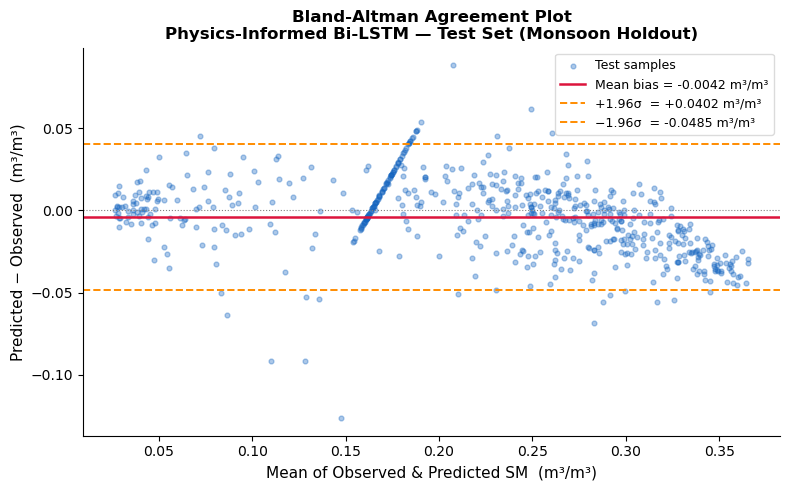


Bland-Altman summary:
  Mean bias  : -0.004191 m³/m³
  Std of diff: 0.022632 m³/m³
  LoA upper  : +0.040167 m³/m³
  LoA lower  : -0.048549 m³/m³


In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Bland-Altman Agreement Plot ─────────────────────────────────────────────
means = (_test_actual_raw + _test_pred_raw) / 2.0
diffs = _test_pred_raw - _test_actual_raw

mean_diff = np.mean(diffs)
std_diff  = np.std(diffs, ddof=1)
loa_upper = mean_diff + 1.96 * std_diff
loa_lower = mean_diff - 1.96 * std_diff

fig_ba, ax = plt.subplots(figsize=(8, 5))
ax.scatter(means, diffs, alpha=0.35, s=12, color='#1565C0', label='Test samples')

ax.axhline(mean_diff, color='crimson',    linewidth=1.8, linestyle='-',
           label=f'Mean bias = {mean_diff:+.4f} m³/m³')
ax.axhline(loa_upper, color='darkorange', linewidth=1.4, linestyle='--',
           label=f'+1.96σ  = {loa_upper:+.4f} m³/m³')
ax.axhline(loa_lower, color='darkorange', linewidth=1.4, linestyle='--',
           label=f'−1.96σ  = {loa_lower:+.4f} m³/m³')
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')

ax.set_xlabel('Mean of Observed & Predicted SM  (m³/m³)', fontsize=11)
ax.set_ylabel('Predicted − Observed  (m³/m³)', fontsize=11)
ax.set_title(
    'Bland-Altman Agreement Plot\n'
    'Physics-Informed Bi-LSTM — Test Set (Monsoon Holdout)',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.7)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f'\nBland-Altman summary:')
print(f'  Mean bias  : {mean_diff:+.6f} m³/m³')
print(f'  Std of diff: {std_diff:.6f} m³/m³')
print(f'  LoA upper  : {loa_upper:+.6f} m³/m³')
print(f'  LoA lower  : {loa_lower:+.6f} m³/m³')